In [ ]:
!pip install -q ultralytics imagehash pillow pandas scikit-learn pyyaml

import os
import shutil
import hashlib
from pathlib import Path

WORK = Path("/content/ppe_project")
RAW = WORK / "raw"
DATASET = WORK / "dataset"

WORK.mkdir(parents=True, exist_ok=True)
RAW.mkdir(parents=True, exist_ok=True)
DATASET.mkdir(parents=True, exist_ok=True)

print("WORK:", WORK)
print("RAW:", RAW)
print("DATASET:", DATASET)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 7.0 MB/s eta 0:00:00
WORK: /content/ppe_project
RAW: /content/ppe_project/raw
DATASET: /content/ppe_project/dataset


In [ ]:
!pip install -q roboflow

In [ ]:
from getpass import getpass
from roboflow import Roboflow

ROBOFLOW_API_KEY = getpass("Enter your Roboflow API Key: ")

rf = Roboflow(api_key=ROBOFLOW_API_KEY)

print("Roboflow connected successfully!")

In [ ]:
workspace = rf.workspace()

print("Workspace connected:", workspace)

In [ ]:
from roboflow import Roboflow

project = rf.workspace("roboflow-universe-projects").project(
    "construction-site-safety"
)

dataset = project.version(27).download(
    "yolov8",
    location="/content/ppe_project/raw/construction_safety"
)

print("Downloaded successfully!")
print("Location:", dataset.location)

In [ ]:
from pathlib import Path
import yaml

CSS = Path("/content/ppe_project/raw/construction_safety")

print("=" * 50)
print("DATASET STRUCTURE")
print("=" * 50)

for item in CSS.iterdir():
    print(item.name, "->", "DIR" if item.is_dir() else "FILE")

print("\n" + "=" * 50)
print("DATA.YAML")
print("=" * 50)

yaml_path = CSS / "data.yaml"

with open(yaml_path, "r") as f:
    css_yaml = yaml.safe_load(f)

print("Classes:")
for i, name in enumerate(css_yaml["names"]):
    print(i, "->", name)

DATASET STRUCTURE
README.dataset.txt -> FILE
train -> DIR
valid -> DIR
data.yaml -> FILE
test -> DIR
README.roboflow.txt -> FILE

DATA.YAML
Classes:
0 -> Hardhat
1 -> Mask
2 -> NO-Hardhat
3 -> NO-Mask
4 -> NO-Safety Vest
5 -> Person
6 -> Safety Cone
7 -> Safety Vest
8 -> machinery
9 -> vehicle


In [ ]:
!pip install -q kaggle

from google.colab import files
files.upload()

In [ ]:
import os
import shutil

os.makedirs("/root/.kaggle", exist_ok=True)

shutil.copy(
    "/content/kaggle (1).json",
    "/root/.kaggle/kaggle.json"
)

os.chmod("/root/.kaggle/kaggle.json", 0o600)

print("Kaggle credentials configured successfully!")

Kaggle credentials configured successfully!


In [ ]:
import os
from pathlib import Path

PPE_DIR = Path("/content/ppe_project/raw/ppe_detection")
PPE_DIR.mkdir(parents=True, exist_ok=True)

!kaggle datasets download -d beyzakucuk/ppe-detection-v1 -p /content/ppe_project/raw/ppe_detection

In [ ]:
import zipfile
from pathlib import Path

zip_path = Path("/content/ppe_project/raw/ppe_detection/ppe-detection-v1.zip")
extract_dir = Path("/content/ppe_project/raw/ppe_detection/data")

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

print("Extracted successfully!")

Extracted successfully!


In [ ]:
from pathlib import Path

print("Top-level contents:\n")

for p in extract_dir.iterdir():
    print("📁" if p.is_dir() else "📄", p.name)

print("\nYAML files:")

for p in extract_dir.rglob("*.yaml"):
    print(p)

Top-level contents:

📄 README.dataset.txt
📁 train
📁 valid
📄 data.yaml
📁 test
📄 README.roboflow.txt

YAML files:
/content/ppe_project/raw/ppe_detection/data/data.yaml


In [ ]:
import yaml

yaml_path = Path("/content/ppe_project/raw/ppe_detection/data/data.yaml")

with open(yaml_path, "r") as f:
    ppe_yaml = yaml.safe_load(f)

print("Classes:")
for i, name in enumerate(ppe_yaml["names"]):
    print(f"{i} -> {name}")

Classes:
0 -> boots
1 -> gloves
2 -> goggles
3 -> helmet
4 -> person
5 -> vest


In [ ]:
for split in ["train", "valid", "test"]:
    img_dir = extract_dir / split / "images"
    lbl_dir = extract_dir / split / "labels"

    images = list(img_dir.glob("*")) if img_dir.exists() else []
    labels = list(lbl_dir.glob("*.txt")) if lbl_dir.exists() else []

    print(f"\n{split.upper()}")
    print("Images:", len(images))
    print("Labels:", len(labels))


TRAIN
Images: 13949
Labels: 13949

VALID
Images: 1669
Labels: 1669

TEST
Images: 1646
Labels: 1646


In [ ]:
from collections import Counter

DATA_ROOT = Path("/content/ppe_project/raw/ppe_detection/data")

class_names = ppe_yaml["names"]

for split in ["train", "valid", "test"]:
    label_dir = DATA_ROOT / split / "labels"
    counter = Counter()

    for label_file in label_dir.glob("*.txt"):
        for line in label_file.read_text().splitlines():
            parts = line.split()
            if parts:
                cls_id = int(parts[0])
                counter[class_names[cls_id]] += 1

    print(f"\n===== {split.upper()} =====")
    for name in class_names:
        print(f"{name:10s}: {counter[name]}")


===== TRAIN =====
boots     : 9920
gloves    : 4878
goggles   : 7557
helmet    : 11108
person    : 5897
vest      : 12192

===== VALID =====
boots     : 1276
gloves    : 653
goggles   : 875
helmet    : 1464
person    : 784
vest      : 1455

===== TEST =====
boots     : 1275
gloves    : 634
goggles   : 907
helmet    : 1430
person    : 723
vest      : 1649


In [ ]:
from pathlib import Path
import shutil

PPE_SRC = Path("/content/ppe_project/raw/ppe_detection/data")
PPE_CONVERTED = Path("/content/ppe_project/raw/ppe_converted")

PPE_CONVERTED.mkdir(parents=True, exist_ok=True)

# Original class IDs
# 0 boots
# 1 gloves
# 2 goggles
# 3 helmet
# 4 person
# 5 vest

PPE_TO_FINAL = {
    3: 0,   # helmet -> hardhat
    4: 4,   # person -> person
    5: 2    # vest -> vest
}

print("Mapping:")
print("helmet -> hardhat")
print("person -> person")
print("vest   -> vest")
print("boots/gloves/goggles -> dropped")

Mapping:
helmet -> hardhat
person -> person
vest   -> vest
boots/gloves/goggles -> dropped


In [ ]:
import shutil
from pathlib import Path

# Original classes
# 0 boots
# 1 gloves
# 2 goggles
# 3 helmet
# 4 person
# 5 vest

PPE_TO_FINAL = {
    3: 0,   # helmet -> hardhat
    4: 4,   # person -> person
    5: 2    # vest -> vest
}

for split in ["train", "valid", "test"]:

    src_img_dir = PPE_SRC / split / "images"
    src_lbl_dir = PPE_SRC / split / "labels"

    dst_img_dir = PPE_CONVERTED / split / "images"
    dst_lbl_dir = PPE_CONVERTED / split / "labels"

    dst_img_dir.mkdir(parents=True, exist_ok=True)
    dst_lbl_dir.mkdir(parents=True, exist_ok=True)

    kept = 0
    dropped = 0
    boxes_created = 0

    for img_path in src_img_dir.glob("*"):

        lbl_path = src_lbl_dir / f"{img_path.stem}.txt"

        if not lbl_path.exists():
            continue

        new_lines = []

        for line in lbl_path.read_text().splitlines():

            parts = line.split()

            if len(parts) < 7:
                continue

            old_id = int(parts[0])

            # Ignore boots / gloves / goggles
            if old_id not in PPE_TO_FINAL:
                continue

            coords = list(map(float, parts[1:]))

            # Segmentation must contain x,y pairs
            if len(coords) < 6 or len(coords) % 2 != 0:
                continue

            xs = coords[0::2]
            ys = coords[1::2]

            # Polygon -> bounding box
            xmin = min(xs)
            xmax = max(xs)
            ymin = min(ys)
            ymax = max(ys)

            xc = (xmin + xmax) / 2
            yc = (ymin + ymax) / 2
            w = xmax - xmin
            h = ymax - ymin

            new_id = PPE_TO_FINAL[old_id]

            new_lines.append(
                f"{new_id} {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}"
            )

            boxes_created += 1

        # Keep only images containing our target classes
        if not new_lines:
            dropped += 1
            continue

        shutil.copy2(
            img_path,
            dst_img_dir / img_path.name
        )

        (dst_lbl_dir / lbl_path.name).write_text(
            "\n".join(new_lines)
        )

        kept += 1

    print(f"\n===== {split.upper()} =====")
    print("Kept images     :", kept)
    print("Dropped images  :", dropped)
    print("Boxes created   :", boxes_created)


===== TRAIN =====
Kept images     : 8482
Dropped images  : 5467
Boxes created   : 29185

===== VALID =====
Kept images     : 1068
Dropped images  : 601
Boxes created   : 3699

===== TEST =====
Kept images     : 1037
Dropped images  : 609
Boxes created   : 3799


In [ ]:
for split in ["train", "valid", "test"]:

    img_dir = PPE_CONVERTED / split / "images"
    lbl_dir = PPE_CONVERTED / split / "labels"

    print(f"\n===== {split.upper()} =====")
    print("Images:", len(list(img_dir.glob("*"))))
    print("Labels:", len(list(lbl_dir.glob("*.txt"))))


===== TRAIN =====
Images: 8482
Labels: 8482

===== VALID =====
Images: 1068
Labels: 1068

===== TEST =====
Images: 1037
Labels: 1037


In [ ]:
from pathlib import Path

CSS_SRC = Path("/content/ppe_project/raw/construction_safety")

print("Exists:", CSS_SRC.exists())
print("Path:", CSS_SRC)

Exists: True
Path: /content/ppe_project/raw/construction_safety


In [ ]:
sample_label = next(
    (CSS_SRC / "train" / "labels").glob("*.txt")
)

print("Sample:", sample_label.name)
print(sample_label.read_text()[:500])

Sample: youtube-554_jpg.rf.157291bf36c5798a05a50da8844b114f.txt
5 0.275 0.209375 0.55 0.41875
6 0.784375 0.209375 0.43125 0.41875
5 0.39609375 0.6328125 0.3453125 0.428125
6 0.63671875 0.89921875 0.1359375 0.2015625
4 0.9028947584860111 0.7221992703898679 0.1399442648307229 0.152371541958086
2 0.9217715026322786 0.609812899878363 0.07677157825883114 0.03638292759490121
5 0.859375 0.7890625 0.246875 0.421875


In [ ]:
CSS_CONVERTED = Path("/content/ppe_project/raw/css_converted")

CSS_TO_FINAL = {
    0: 0,  # Hardhat
    2: 1,  # NO-Hardhat
    7: 2,  # Safety Vest
    4: 3,  # NO-Safety Vest
    5: 4   # Person
}

for split in ["train", "valid", "test"]:

    src_img_dir = CSS_SRC / split / "images"
    src_lbl_dir = CSS_SRC / split / "labels"

    dst_img_dir = CSS_CONVERTED / split / "images"
    dst_lbl_dir = CSS_CONVERTED / split / "labels"

    dst_img_dir.mkdir(parents=True, exist_ok=True)
    dst_lbl_dir.mkdir(parents=True, exist_ok=True)

    kept = 0
    dropped = 0
    boxes = 0

    for img_path in src_img_dir.glob("*"):

        lbl_path = src_lbl_dir / f"{img_path.stem}.txt"

        if not lbl_path.exists():
            continue

        new_lines = []

        for line in lbl_path.read_text().splitlines():

            parts = line.split()

            if len(parts) != 5:
                continue

            old_id = int(parts[0])

            if old_id not in CSS_TO_FINAL:
                continue

            parts[0] = str(CSS_TO_FINAL[old_id])

            new_lines.append(" ".join(parts))
            boxes += 1

        if not new_lines:
            dropped += 1
            continue

        shutil.copy2(
            img_path,
            dst_img_dir / img_path.name
        )

        (dst_lbl_dir / lbl_path.name).write_text(
            "\n".join(new_lines)
        )

        kept += 1

    print(f"\n===== {split.upper()} =====")
    print("Kept images    :", kept)
    print("Dropped images :", dropped)
    print("Boxes          :", boxes)


===== TRAIN =====
Kept images    : 2515
Dropped images : 88
Boxes          : 22484

===== VALID =====
Kept images    : 84
Dropped images : 30
Boxes          : 461

===== TEST =====
Kept images    : 60
Dropped images : 22
Boxes          : 476


In [ ]:
from collections import Counter

FINAL_NAMES = {
    0: "hardhat",
    1: "no-hardhat",
    2: "vest",
    3: "no-vest",
    4: "person"
}

for split in ["train", "valid", "test"]:

    label_dir = CSS_CONVERTED / split / "labels"
    counter = Counter()

    for label_file in label_dir.glob("*.txt"):
        for line in label_file.read_text().splitlines():
            parts = line.split()

            if len(parts) == 5:
                cls_id = int(parts[0])
                counter[FINAL_NAMES[cls_id]] += 1

    print(f"\n===== {split.upper()} =====")

    for cls_id, name in FINAL_NAMES.items():
        print(f"{name:12s}: {counter[name]}")


===== TRAIN =====
hardhat     : 3362
no-hardhat  : 2318
vest        : 3156
no-vest     : 3957
person      : 9691

===== VALID =====
hardhat     : 79
no-hardhat  : 69
vest        : 41
no-vest     : 106
person      : 166

===== TEST =====
hardhat     : 110
no-hardhat  : 41
vest        : 61
no-vest     : 90
person      : 174


In [ ]:
from collections import Counter

def get_image_stems(root):
    stems = set()

    for split in ["train", "valid", "test"]:
        img_dir = root / split / "images"

        if img_dir.exists():
            for img in img_dir.glob("*"):
                stems.add(img.stem)

    return stems


ppe_stems = get_image_stems(PPE_CONVERTED)
css_stems = get_image_stems(CSS_CONVERTED)

overlap = ppe_stems & css_stems

print("PPE images:", len(ppe_stems))
print("CSS images:", len(css_stems))
print("Same-name overlap:", len(overlap))

if overlap:
    print("\nExamples:")
    for x in list(overlap)[:10]:
        print(x)

PPE images: 10587
CSS images: 2659
Same-name overlap: 0


Merge

In [ ]:
import pandas as pd
import random
import shutil
from pathlib import Path

FINAL_DATASET = Path("/content/ppe_project/dataset")

# Clean old dataset if it exists
if FINAL_DATASET.exists():
    shutil.rmtree(FINAL_DATASET)

for split in ["train", "val", "test"]:
    (FINAL_DATASET / split / "images").mkdir(parents=True, exist_ok=True)
    (FINAL_DATASET / split / "labels").mkdir(parents=True, exist_ok=True)


def build_manifest(root, source_name):
    rows = []

    for original_split in ["train", "valid", "test"]:
        img_dir = root / original_split / "images"
        lbl_dir = root / original_split / "labels"

        if not img_dir.exists():
            continue

        for img_path in img_dir.glob("*"):
            lbl_path = lbl_dir / f"{img_path.stem}.txt"

            if lbl_path.exists():
                rows.append({
                    "image_path": str(img_path),
                    "label_path": str(lbl_path),
                    "source": source_name
                })

    return pd.DataFrame(rows)


ppe_df = build_manifest(PPE_CONVERTED, "PPE_V1")
css_df = build_manifest(CSS_CONVERTED, "Construction_Safety")

manifest = pd.concat(
    [ppe_df, css_df],
    ignore_index=True
)

print("Total images:", len(manifest))
print("\nBy source:")
print(manifest["source"].value_counts())

Total images: 13246

By source:
source
PPE_V1                 10587
Construction_Safety     2659
Name: count, dtype: int64


Split 80/10/10

In [ ]:
from sklearn.model_selection import train_test_split

train_parts = []
val_parts = []
test_parts = []

for source, group in manifest.groupby("source"):

    train_df, temp_df = train_test_split(
        group,
        test_size=0.20,
        random_state=42,
        shuffle=True
    )

    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.50,
        random_state=42,
        shuffle=True
    )

    train_parts.append(train_df)
    val_parts.append(val_df)
    test_parts.append(test_df)

train_df = pd.concat(train_parts, ignore_index=True)
val_df = pd.concat(val_parts, ignore_index=True)
test_df = pd.concat(test_parts, ignore_index=True)

print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))
print("Total:", len(train_df) + len(val_df) + len(test_df))

print("\n===== SOURCE DISTRIBUTION =====")

for name, df in [
    ("TRAIN", train_df),
    ("VAL", val_df),
    ("TEST", test_df)
]:
    print(f"\n{name}")
    print(df["source"].value_counts())

Train: 10596
Val  : 1325
Test : 1325
Total: 13246

===== SOURCE DISTRIBUTION =====

TRAIN
source
PPE_V1                 8469
Construction_Safety    2127
Name: count, dtype: int64

VAL
source
PPE_V1                 1059
Construction_Safety     266
Name: count, dtype: int64

TEST
source
PPE_V1                 1059
Construction_Safety     266
Name: count, dtype: int64


In [ ]:
def copy_split(df, split_name):

    img_out = FINAL_DATASET / split_name / "images"
    lbl_out = FINAL_DATASET / split_name / "labels"

    for _, row in df.iterrows():

        src_img = Path(row["image_path"])
        src_lbl = Path(row["label_path"])

        shutil.copy2(
            src_img,
            img_out / src_img.name
        )

        shutil.copy2(
            src_lbl,
            lbl_out / src_lbl.name
        )

    print(
        split_name.upper(),
        "->",
        len(df),
        "images"
    )


copy_split(train_df, "train")
copy_split(val_df, "val")
copy_split(test_df, "test")

TRAIN -> 10596 images
VAL -> 1325 images
TEST -> 1325 images


In [ ]:
yaml_content = """
path: /content/ppe_project/dataset

train: train/images
val: val/images
test: test/images

names:
  0: hardhat
  1: no-hardhat
  2: vest
  3: no-vest
  4: person
"""

(FINAL_DATASET / "data.yaml").write_text(yaml_content)

print(yaml_content)


path: /content/ppe_project/dataset

train: train/images
val: val/images
test: test/images

names:
  0: hardhat
  1: no-hardhat
  2: vest
  3: no-vest
  4: person



In [ ]:
from collections import Counter

CLASS_NAMES = {
    0: "hardhat",
    1: "no-hardhat",
    2: "vest",
    3: "no-vest",
    4: "person"
}

for split in ["train", "val", "test"]:

    label_dir = FINAL_DATASET / split / "labels"

    counter = Counter()

    for label_file in label_dir.glob("*.txt"):

        for line in label_file.read_text().splitlines():

            parts = line.split()

            if len(parts) == 5:
                cls_id = int(parts[0])
                counter[cls_id] += 1

    print(f"\n===== {split.upper()} =====")

    for cls_id, name in CLASS_NAMES.items():
        print(f"{name:12s}: {counter[cls_id]}")


===== TRAIN =====
hardhat     : 13984
no-hardhat  : 1964
vest        : 14859
no-vest     : 3304
person      : 13980

===== VAL =====
hardhat     : 1759
no-hardhat  : 230
vest        : 1725
no-vest     : 451
person      : 1738

===== TEST =====
hardhat     : 1792
no-hardhat  : 234
vest        : 1969
no-vest     : 398
person      : 1717


Training

In [ ]:
RUN_PROJECT = "/content/ppe_project/runs"
RUN_NAME = "yolo11s_adamw_baseline"

from ultralytics import YOLO

MODEL = YOLO("yolo11s.pt")

results = MODEL.train(
    data="/content/ppe_project/dataset/data.yaml",

    epochs=60,
    imgsz=640,
    batch=16,
    device=0,
    patience=15,
    optimizer='AdamW',
    lr0=0.001,
    lrf=0.01,
    weight_decay=0.0005,
    warmup_epochs=3,
    mosaic=1.0,
    mixup=0.1,
    degrees=5,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    project=RUN_PROJECT,
    name=RUN_NAME,
    save=True,
    plots=True,
    verbose=True
)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
New https://pypi.org/project/ultralytics/8.4.137 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.136 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/ppe_project/dataset/data.yaml, degrees=5, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0

In [ ]:
from ultralytics import YOLO

BEST_MODEL = "/content/ppe_project/runs/yolo11s_adamw_baseline/weights/best.pt"

best_model = YOLO(BEST_MODEL)

print("Best model loaded successfully!")

Best model loaded successfully!


Validation

In [ ]:
val_results = best_model.val(
    data="/content/ppe_project/dataset/data.yaml",
    imgsz=640,
    batch=16,
    device=0,
    plots=True
)

Ultralytics 8.4.136 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,414,735 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1808.5±672.5 MB/s, size: 57.6 KB)
val: Scanning /content/ppe_project/dataset/val/labels.cache... 1325 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1325/1325 505.2Mit/s 0.0s
val: /content/ppe_project/dataset/val/images/000637_jpg.rf.fe0f7229170051fe8171c4fa43e8c383.jpg: 1 duplicate labels removed
val: /content/ppe_project/dataset/val/images/Aitin3617_jpg.rf.02f382d42c6cab30895fe0031d617478.jpg: 2 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 83/83 3.4it/s 24.7s
                   all       1325       5900      0.805      0.723      0.783      0.561
               hardhat        698       1759      0.781      0.754      0.797      0.604
            no-hardhat        145        230 

In [ ]:
print("Precision:", val_results.box.mp)
print("Recall   :", val_results.box.mr)
print("mAP50    :", val_results.box.map50)
print("mAP50-95 :", val_results.box.map)

print("\nPer-class mAP50:")
for name, score in zip(
    best_model.names.values(),
    val_results.box.maps
):
    print(f"{name:12s}: {score:.4f}")

Precision: 0.8053200813703217
Recall   : 0.7225284918338316
mAP50    : 0.7831008554463079
mAP50-95 : 0.5611413138735142

Per-class mAP50:
hardhat     : 0.6037
no-hardhat  : 0.4673
vest        : 0.6694
no-vest     : 0.5003
person      : 0.5651


Confusion Matrix:


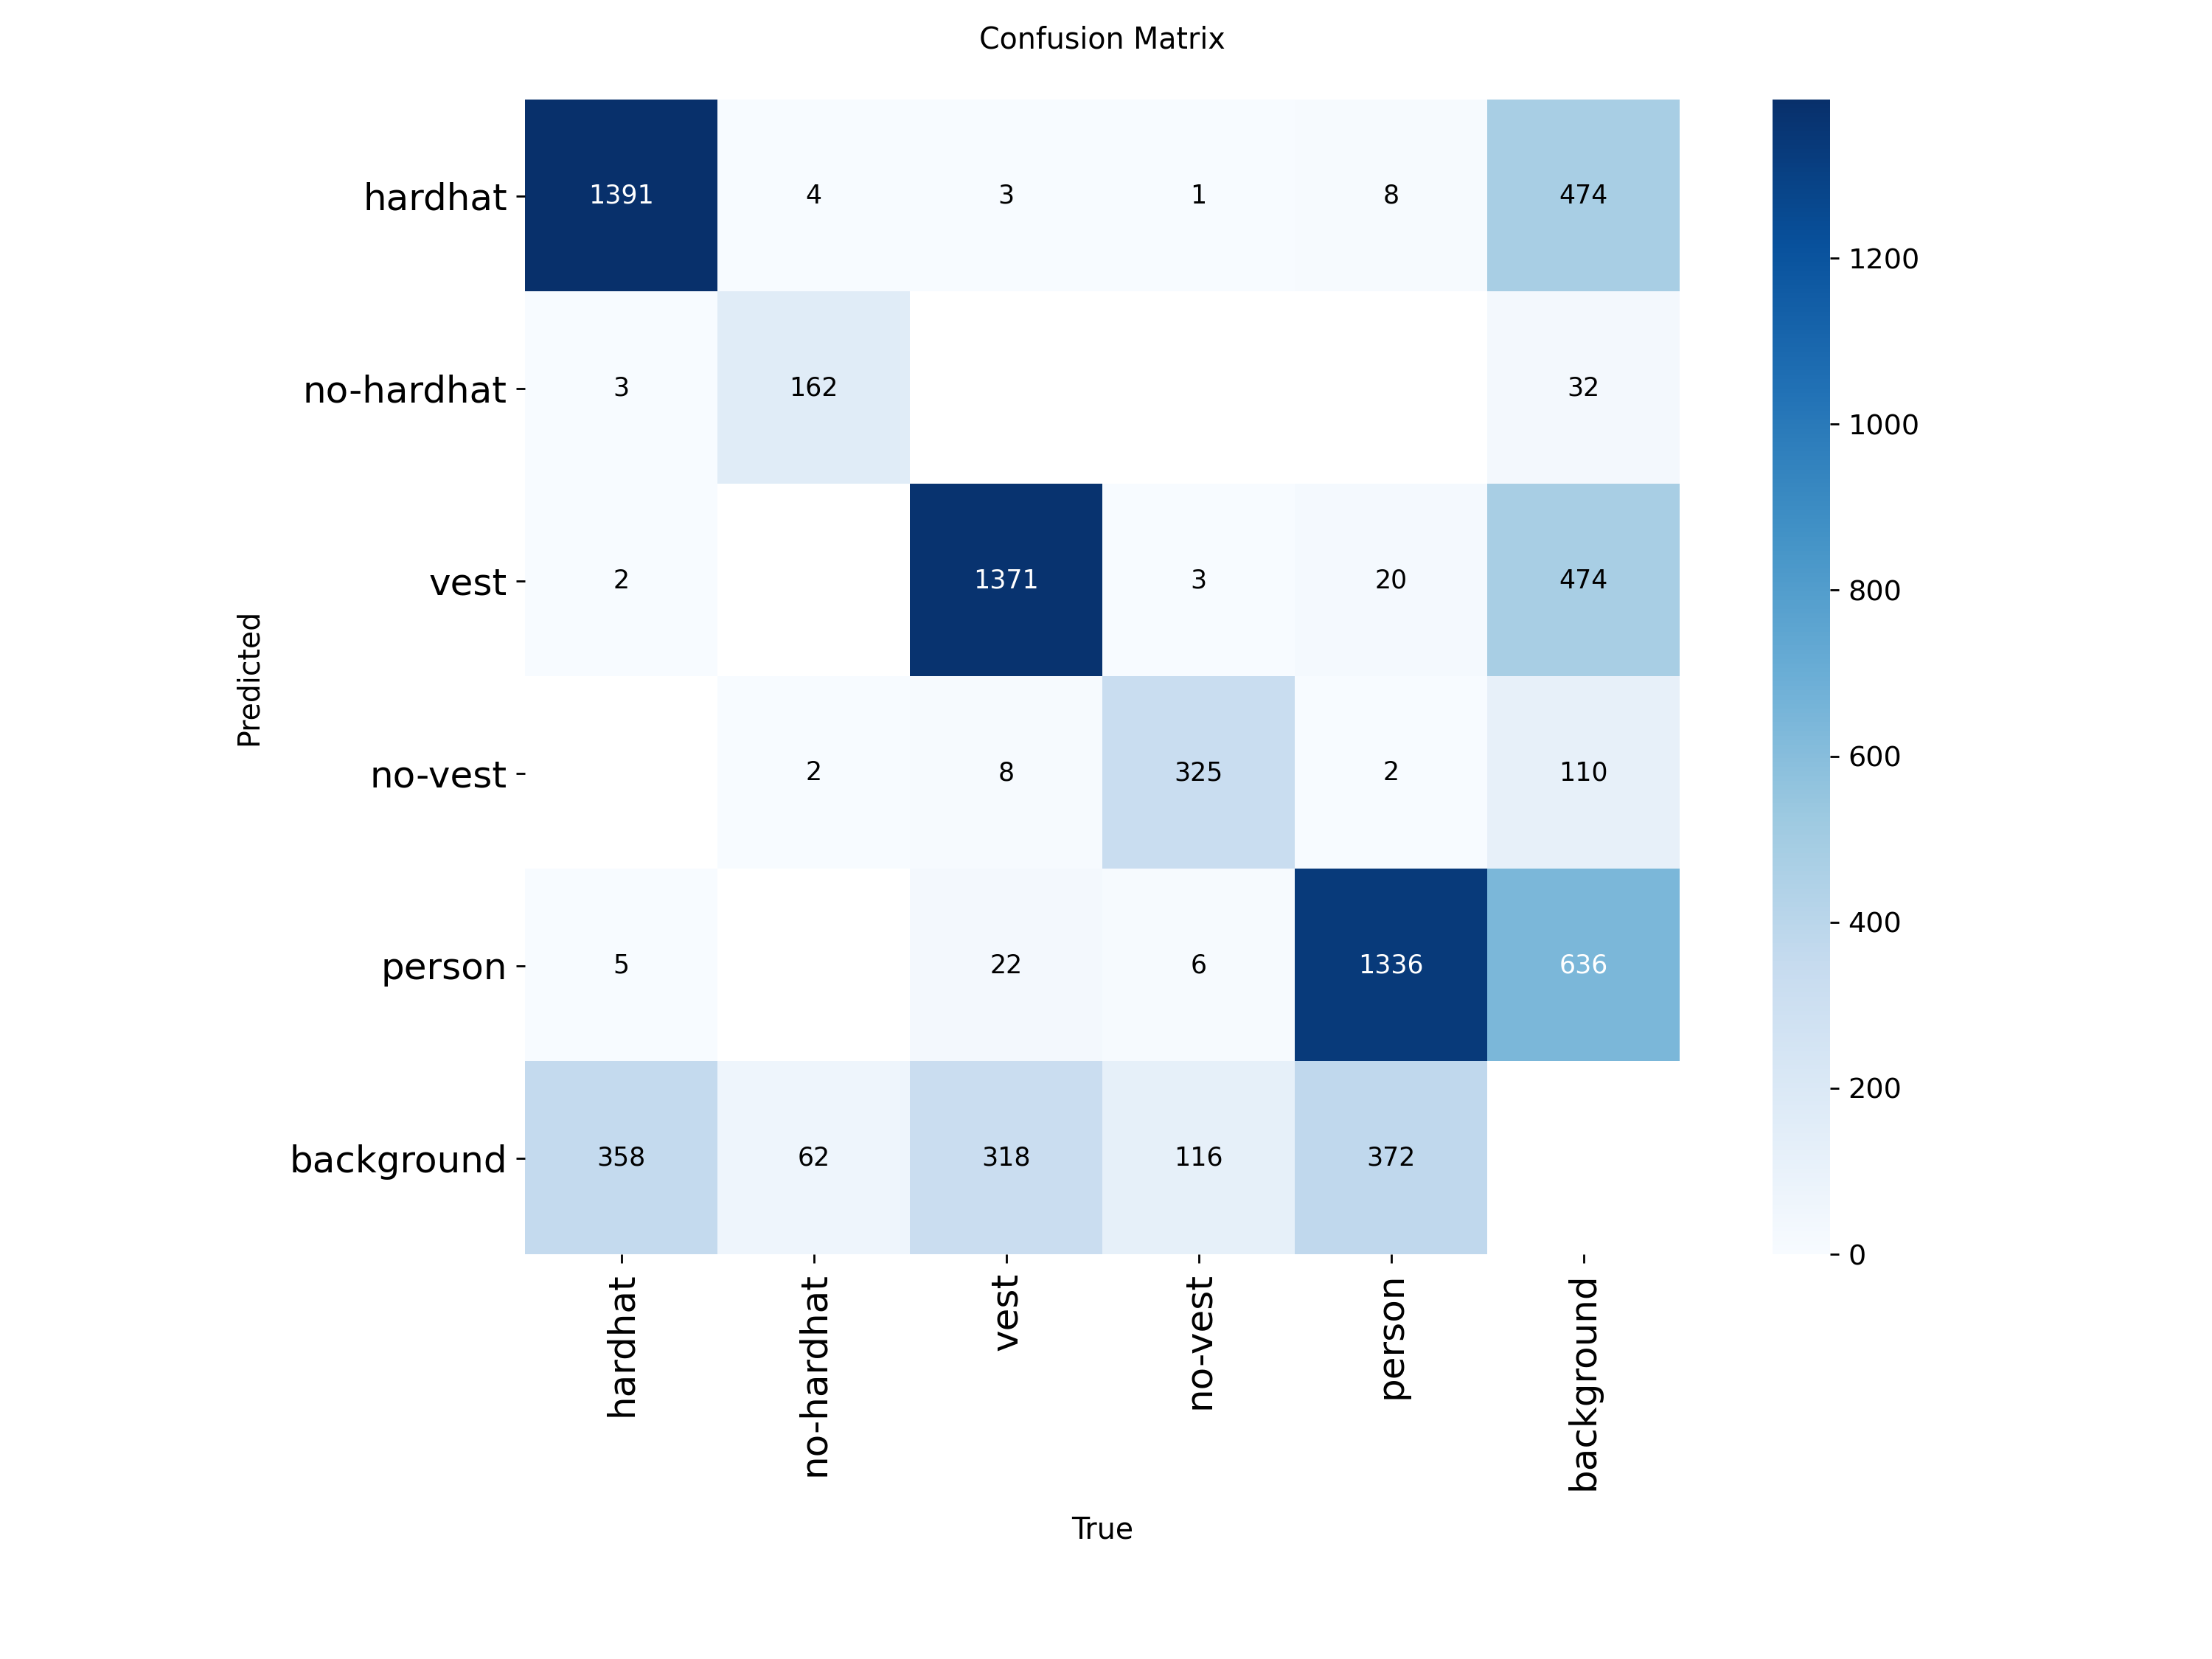

In [ ]:
from pathlib import Path
from IPython.display import Image, display

save_dir = Path(val_results.save_dir)

cm_path = save_dir / "confusion_matrix.png"

print("Confusion Matrix:")
display(Image(filename=str(cm_path)))

Normalized Confusion Matrix:


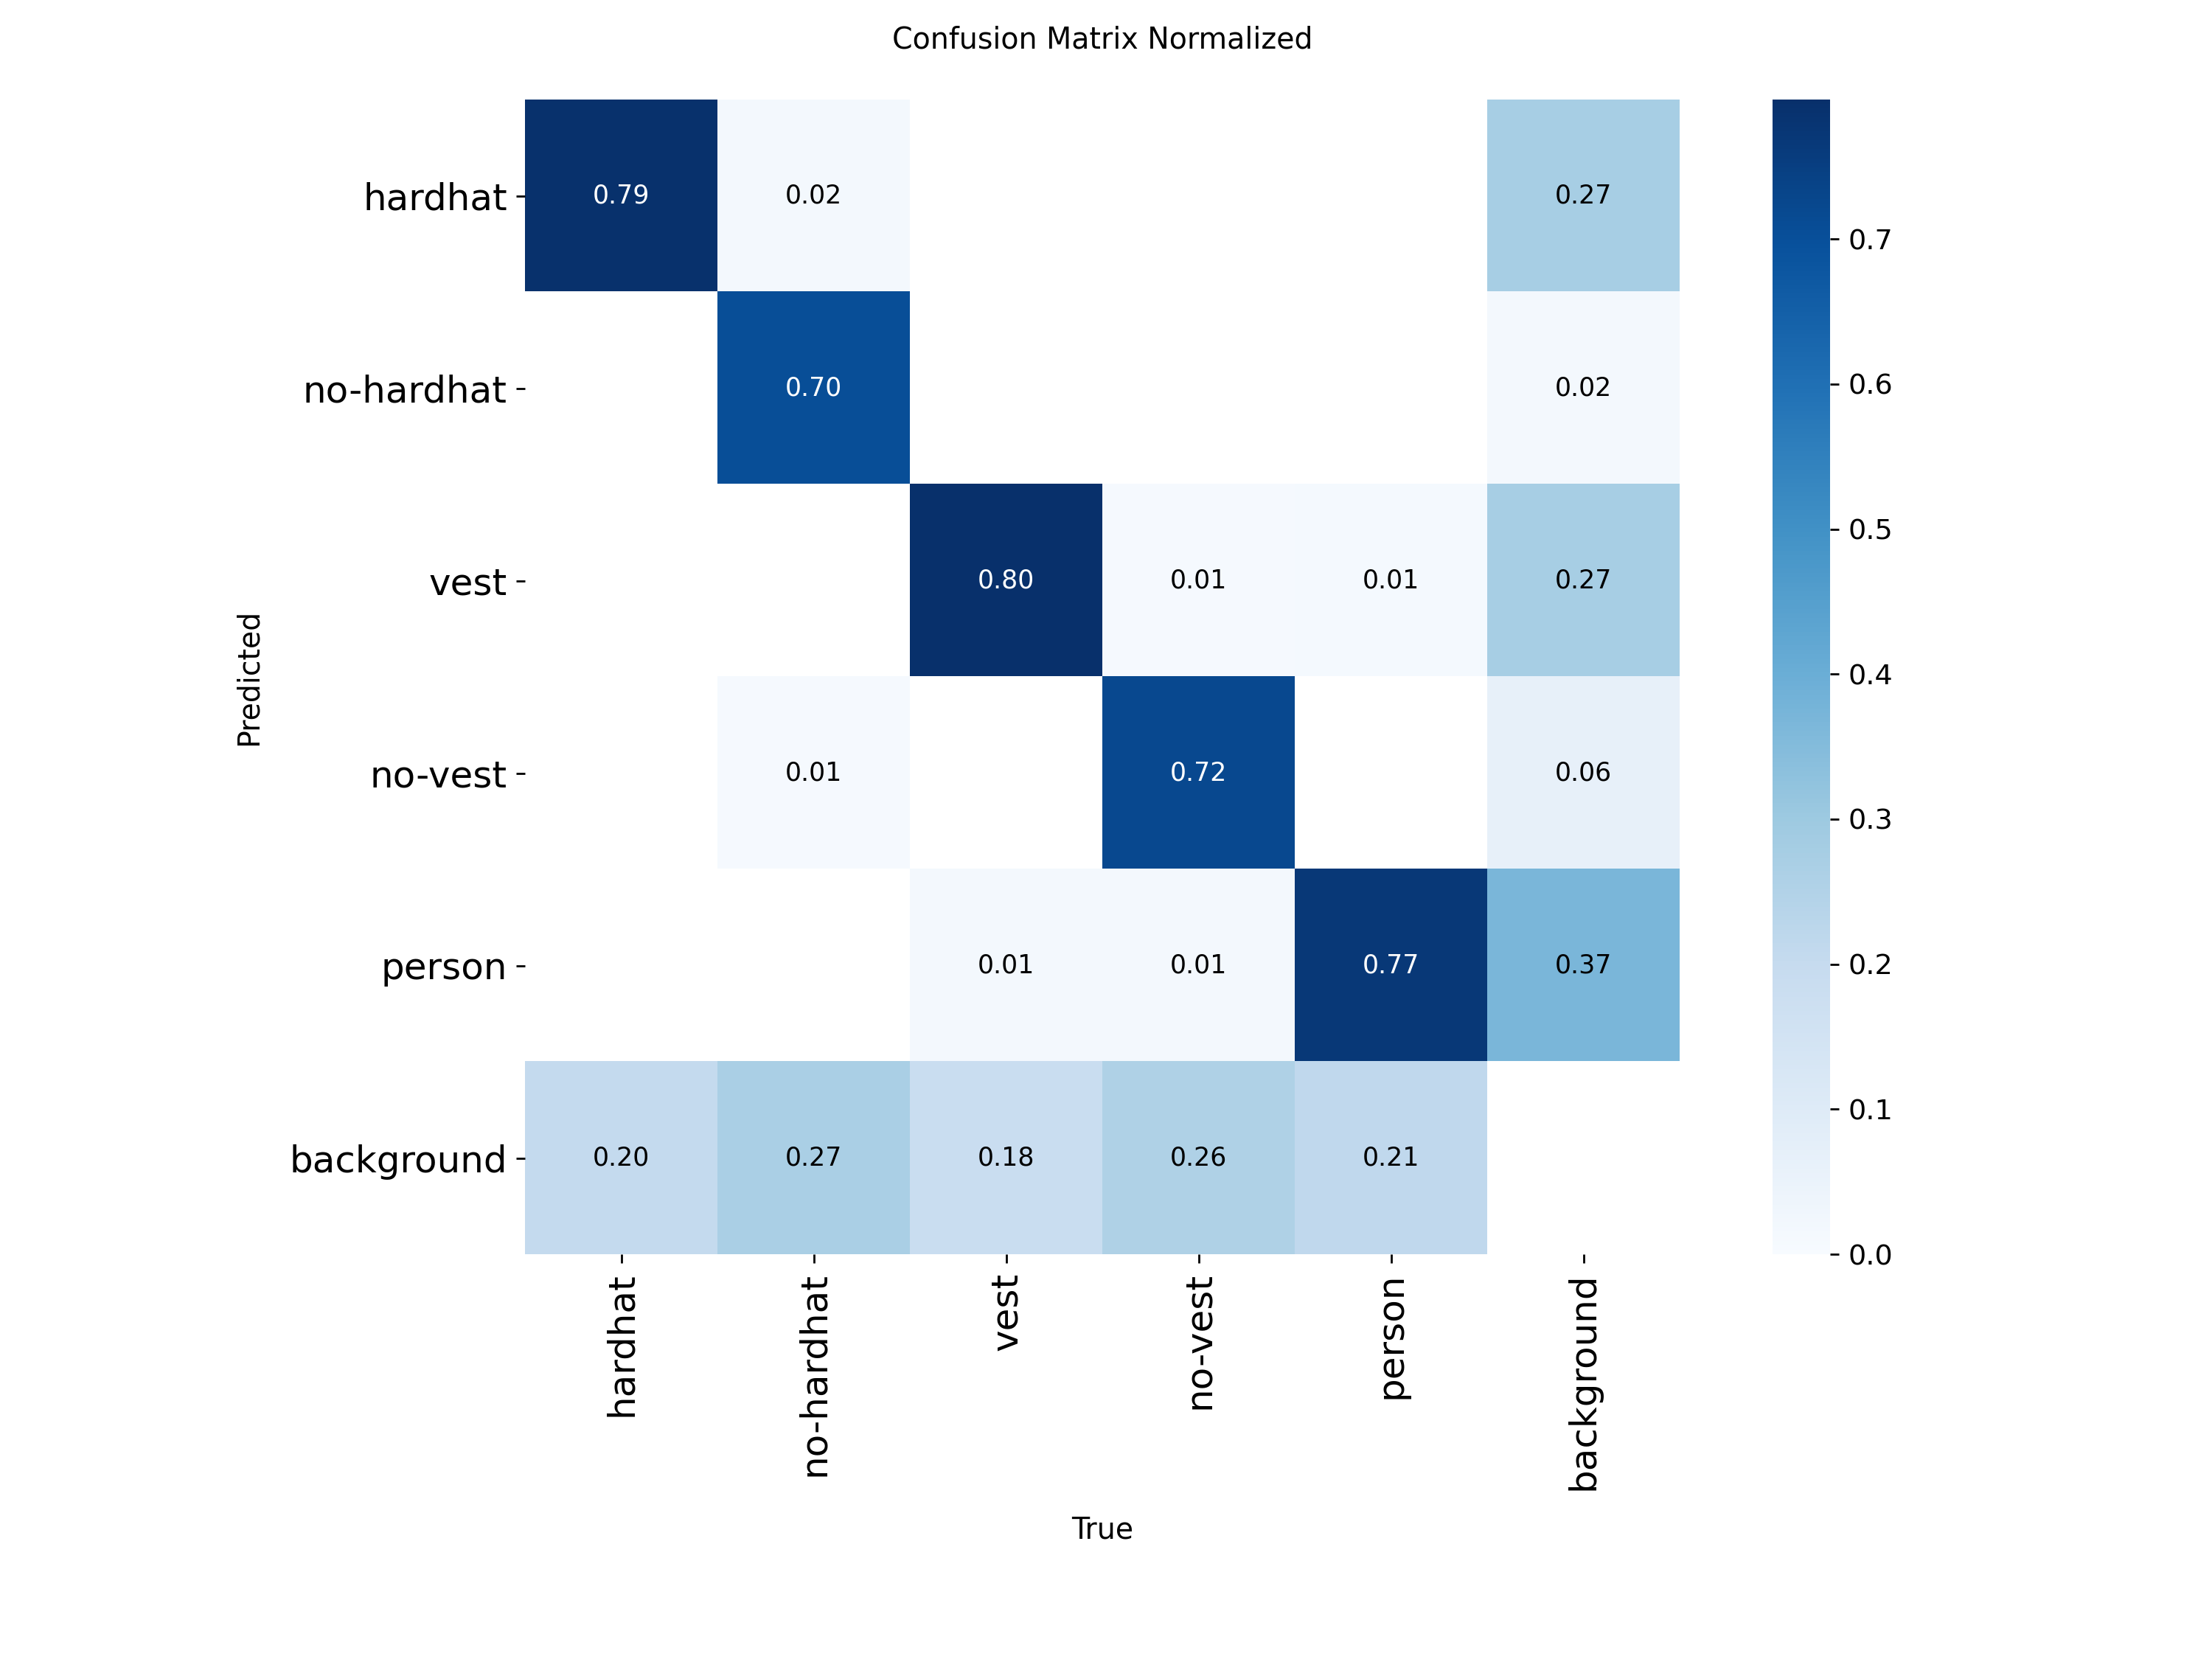

In [ ]:
cm_normalized_path = save_dir / "confusion_matrix_normalized.png"

print("Normalized Confusion Matrix:")
display(Image(filename=str(cm_normalized_path)))

Val Evaluation

In [ ]:
test_results = best_model.val(
    data="/content/ppe_project/dataset/data.yaml",
    split="test",
    imgsz=640,
    batch=16,
    device=0,
    plots=True
)

print("TEST Precision:", test_results.box.mp)
print("TEST Recall   :", test_results.box.mr)
print("TEST mAP50    :", test_results.box.map50)
print("TEST mAP50-95 :", test_results.box.map)

Ultralytics 8.4.136 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 20.2±16.1 MB/s, size: 52.8 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /content/ppe_project/dataset/test/labels... 1325 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1325/1325 580.1it/s 2.3s
val: New cache created: /content/ppe_project/dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 83/83 3.8it/s 21.7s
                   all       1325       6110      0.818        0.7      0.781      0.573
               hardhat        678       1792      0.812      0.728      0.808      0.616
            no-hardhat        142        234      0.878      0.675      0.761      0.502
                  vest        738       1969      0.815      0.756      0.

In [ ]:
import os

BEST_MODEL = "/content/ppe_project/runs/yolo11s_adamw_baseline/weights/best.pt"

print(os.path.exists(BEST_MODEL))

True


In [ ]:
from ultralytics import YOLO

BEST_MODEL = "/content/ppe_project/runs/yolo11s_adamw_baseline/weights/best.pt"

best_model = YOLO(BEST_MODEL)

print("Best model loaded successfully!")

Best model loaded successfully!


In [ ]:
import os

print("Folder exists:", os.path.exists(NEW_IMAGES))
print("Path:", NEW_IMAGES)

if os.path.exists(NEW_IMAGES):
    print("Files:")
    print(os.listdir(NEW_IMAGES))

Folder exists: True
Path: /content/ppe_project/new_test_images
Files:
[]


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving OIP (1).webp to OIP (1).webp


In [ ]:
import os
import shutil

NEW_IMAGES = "/content/ppe_project/new_test_images"

os.makedirs(NEW_IMAGES, exist_ok=True)

for filename in uploaded.keys():
    shutil.move(
        f"/content/{filename}",
        f"{NEW_IMAGES}/{filename}"
    )

print(os.listdir(NEW_IMAGES))

['OIP (1).webp']


In [ ]:
predictions = best_model.predict(
    source=str(NEW_IMAGES),
    imgsz=640,
    conf=0.25,
    save=True
)


image 1/1 /content/ppe_project/new_test_images/OIP (1).webp: 352x640 1 vest, 10.7ms
Speed: 1.7ms preprocess, 10.7ms inference, 1.5ms postprocess per image at shape (1, 3, 352, 640)
Results saved to /content/runs/detect/predict


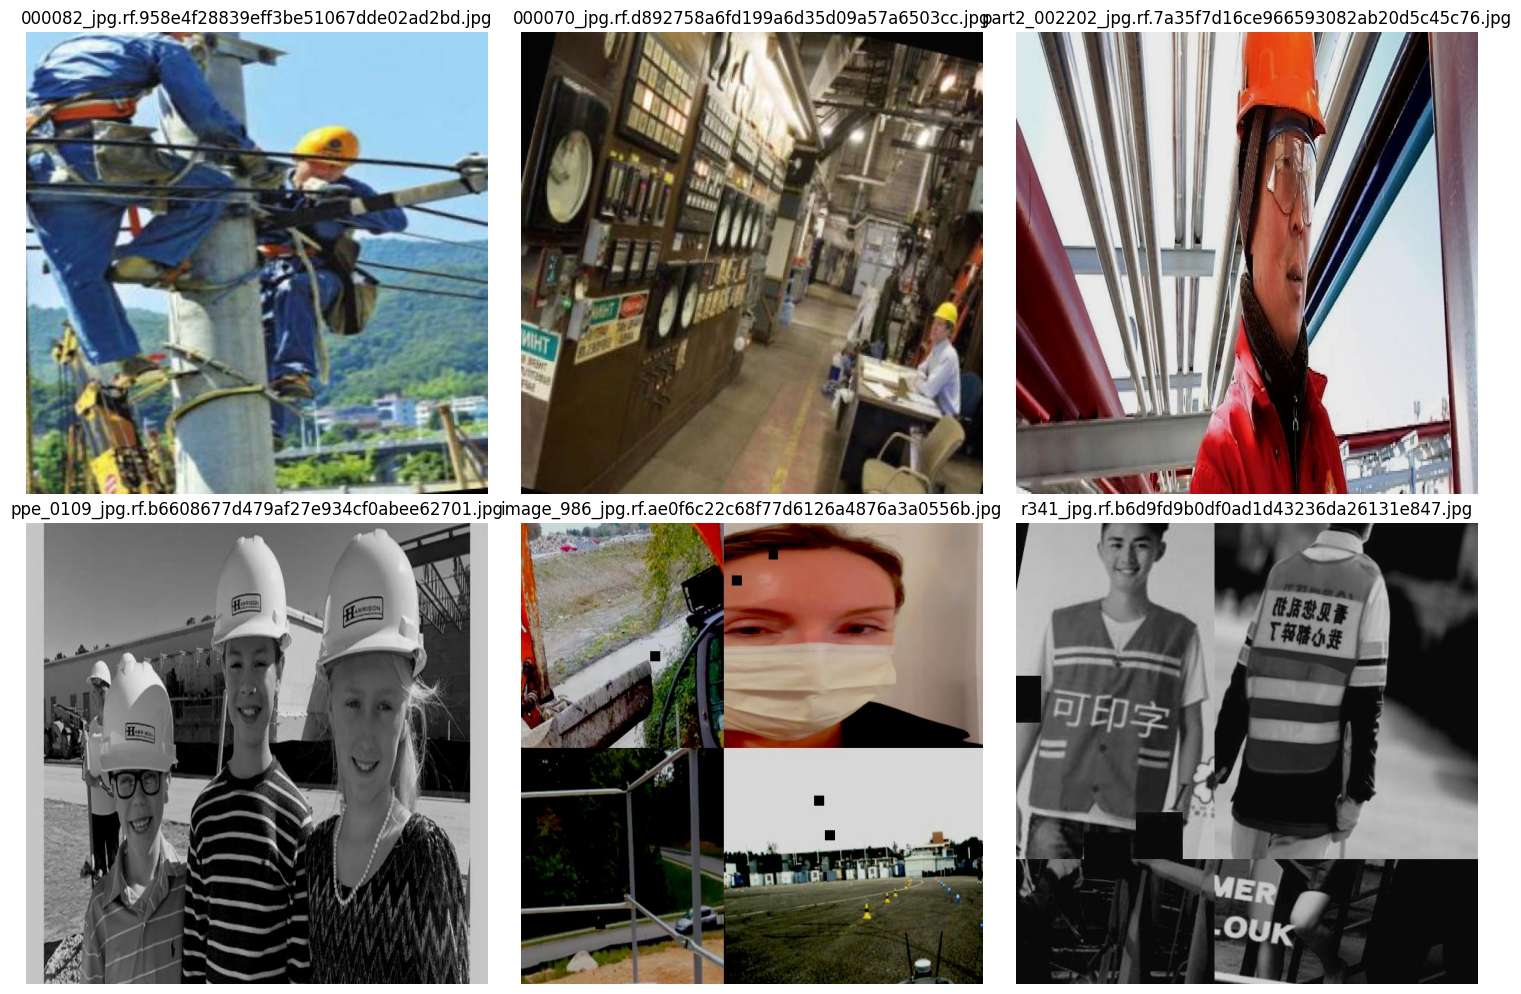

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

IMAGE_DIR = "/content/ppe_project/dataset/val/images"

images = [
    os.path.join(IMAGE_DIR, f)
    for f in os.listdir(IMAGE_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]
selected_images = random.sample(images, 6)

plt.figure(figsize=(15, 10))

for i, img_path in enumerate(selected_images):
    img = Image.open(img_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(os.path.basename(img_path))

plt.tight_layout()
plt.show()

In [ ]:
from ultralytics import YOLO
from pathlib import Path

best_model = YOLO(str(BEST_MODEL))

VAL_IMAGES = Path("/content/ppe_project/dataset/val/images")

predictions = best_model.predict(
    source=str(VAL_IMAGES),
    imgsz=640,
    conf=0.25,
    save=True
)

print("Detection completed!")


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1325 /content/ppe_project/dataset/val/images/-1670-_png_jpg.rf.2ef0952f6731ec685d1d25d38a6e934c.jpg: 640x640 1 no-hardhat, 2 no-vests, 3 persons, 15.4ms
image 2/1325 /content/ppe_project/dataset/val/images/-1680-_png_jpg.rf.22742422c61f16531181cfd14230ad7c.jpg: 640x640 2 persons, 15.4ms
image 3/1325 /content/ppe_project/dataset/val/images/-1975-_png_jpg.rf.52e99d7040a4ec25730fd0d8654de5c7.jpg: 640x640 1 hardhat, 3 no-hardhats, 5 no-vests, 6 person

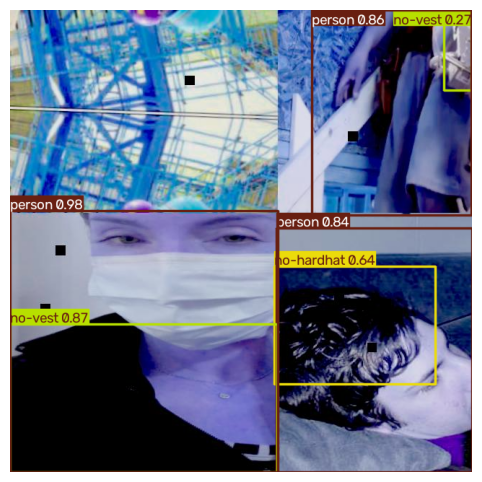

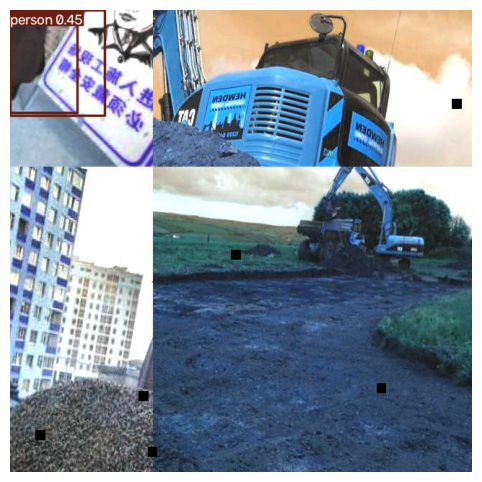

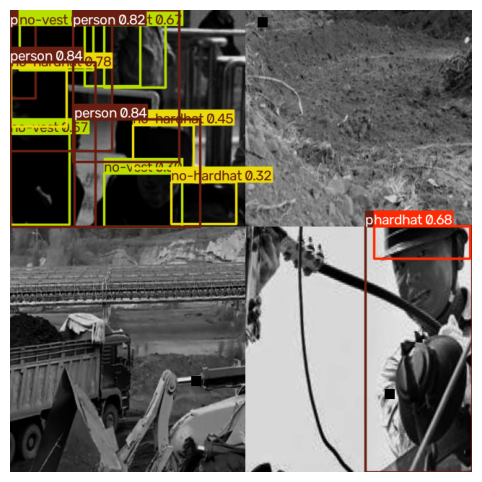

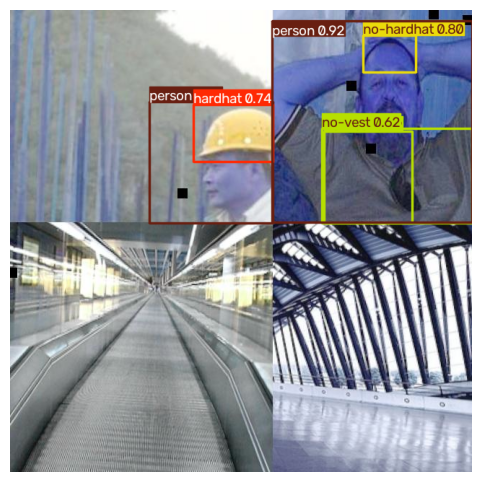

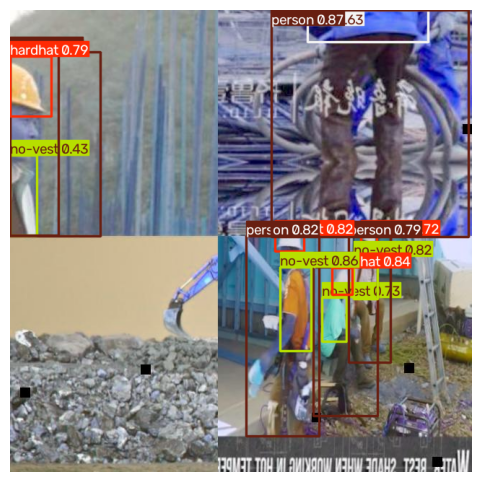

In [ ]:
import matplotlib.pyplot as plt

for result in predictions[:5]:
    img = result.plot()

    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving OIP.webp to OIP (1).webp


In [ ]:
from pathlib import Path
import shutil

NEW_IMAGES = Path("/content/ppe_project/new_test_images")
NEW_IMAGES.mkdir(parents=True, exist_ok=True)

for filename in uploaded.keys():
    shutil.move(filename, NEW_IMAGES / filename)

print("Images added:")
for img in NEW_IMAGES.iterdir():
    print(img.name)

Images added:
OIP (1).webp


In [ ]:
predictions = best_model.predict(
    source=str(NEW_IMAGES),
    imgsz=640,
    conf=0.25,
    save=True
)

print("Detection completed!")


image 1/1 /content/ppe_project/new_test_images/OIP (1).webp: 640x448 1 hardhat, 1 vest, 1 person, 92.6ms
Speed: 2.7ms preprocess, 92.6ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 448)
Results saved to /content/runs/detect/predict-3
Detection completed!


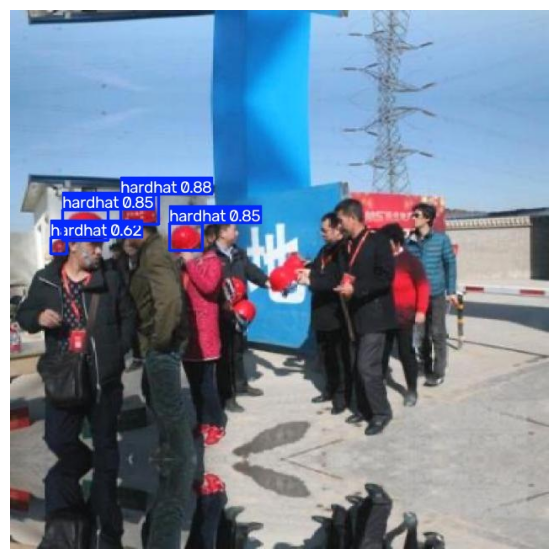

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

RESULT_DIR = Path("/content/runs/detect/predict-3")

result_image = next(
    p for p in RESULT_DIR.iterdir()
    if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".webp"]
)

img = Image.open(result_image)

plt.figure(figsize=(10, 7))
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
from pathlib import Path

BASE_MODEL = Path("/content/yolo11s.pt")

print("Base model exists:", BASE_MODEL.exists())

Base model exists: True


In [ ]:
from ultralytics import YOLO

base_model = YOLO(str(BASE_MODEL))

base_onnx = base_model.export(
    format="onnx"
)

print("Base model exported successfully!")
print(base_onnx)

Ultralytics 8.4.136 🚀 Python-3.13.15 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino
YOLO11s summary (fused): 100 layers, 9,443,760 parameters, 0 gradients, 21.6 GFLOPs

PyTorch: starting from '/content/yolo11s.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (18.4 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 12 packages in 334ms
Prepared 4 packages in 1.85s
Installed 4 packages in 253ms
 + colorama==0.4.6
 + onnx==1.22.0
 + onnxruntime==1.29.0
 + onnxslim==0.1.96

requirements: AutoUpdate success ✅ 3.0s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 18...
ONNX: slimming with onnxslim 0.1.96..

In [ ]:
from pathlib import Path

for p in Path("/content").glob("*.onnx"):
    print(p)

/content/yolo11s.onnx


In [ ]:
best_model = YOLO(str(BEST_MODEL))

trained_onnx = best_model.export(
    format="onnx"
)

print("Trained PPE model exported successfully!")
print(trained_onnx)

Ultralytics 8.4.136 🚀 Python-3.13.15 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
YOLO11s summary (fused): 101 layers, 9,414,735 parameters, 0 gradients, 21.4 GFLOPs

PyTorch: starting from '/content/ppe_project/runs/yolo11s_adamw_baseline/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 9, 8400) (18.3 MB)

ONNX: starting export with onnx 1.22.0 opset 18...
ONNX: slimming with onnxslim 0.1.96...
ONNX: export success ✅ 1.8s, saved as '/content/ppe_project/runs/yolo11s_adamw_baseline/weights/best.onnx' (36.2 MB)

Export complete (2.7s)
Results saved to /content/ppe_project/runs/yolo11s_adamw_baseline/weights/best.onnx
Predict:         yolo predict task=detect model=/content/ppe_project/runs/yolo11s_adamw_baseline/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/content/ppe_project/runs/yolo11s_adamw_baseline/weights/best.onnx imgsz=640 data=/content/ppe_project/dataset/data.yaml  
Visualize:       https://netron.app
Trained PPE

In [ ]:
from google.colab import files

files.download(
    "/content/ppe_project/runs/yolo11s_adamw_baseline/weights/best.pt"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(open("/content/ppe_project/dataset/data.yaml").read())


path: /content/ppe_project/dataset

train: train/images
val: val/images
test: test/images

names:
  0: hardhat
  1: no-hardhat
  2: vest
  3: no-vest
  4: person

